### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder

### Configurations

In [2]:
data_path = "data\Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2016_20260513.csv"

<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\apoor\AppData\Local\Temp\ipykernel_24908\3016185725.py:1: SyntaxWarning: invalid escape sequence '\H'
  data_path = "data\Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2016_20260513.csv"


## Exploratory Data Analysis

In [3]:
db_main = pd.read_csv(data_path)
db_main.head()

C:\Users\apoor\AppData\Local\Temp\ipykernel_24908\3709795038.py:1: DtypeWarning: Columns (0: Facility Id, 1: Length of Stay) have mixed types. Specify dtype option on import or set low_memory=False.
  db_main = pd.read_csv(data_path)


,Health Service Area,Hospital County,Operating Certificate Number,Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Abortion Edit Indicator,Emergency Department Indicator,Total Charges,Total Costs
0,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,F,White,Not Span/Hispanic,...,Moderate,Medical,Medicare,Private Health Insurance,NaN,0,N,N,"$3,913.23","$3,466.83"
1,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,30 to 49,147,M,White,Not Span/Hispanic,...,Minor,Medical,Self-Pay,NaN,NaN,0,N,Y,"$3,597.1","$3,746.8"
2,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,50 to 69,147,F,White,Not Span/Hispanic,...,Minor,Medical,Medicare,Federal/State/Local/VA,NaN,0,N,Y,"$9,149.22","$8,322.1"
3,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,M,White,Not Span/Hispanic,...,Moderate,Medical,Medicare,Medicaid,NaN,0,N,Y,"$5,880.61","$5,828.87"
4,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,50 to 69,147,M,White,Not Span/Hispanic,...,Moderate,Medical,Blue Cross/Blue Shield,NaN,NaN,0,N,Y,"$7,019.76","$6,604"


In [4]:
print(db_main.shape)

(2343429, 34)


In [5]:
db_main.describe()

,Operating Certificate Number,Discharge Year,CCS Diagnosis Code,CCS Procedure Code,APR DRG Code,APR MDC Code,APR Severity of Illness Code,Birth Weight
count,2.338104e+06,2343429.0,2.343429e+06,2.343429e+06,2.343429e+06,2.343429e+06,2.343429e+06,2.343429e+06
mean,4.989377e+06,2016.0,1.906030e+02,1.046221e+02,4.165046e+02,1.032289e+01,2.024331e+00,3.190755e+02
std,2.265922e+06,0.0,1.613759e+02,8.958427e+01,2.425629e+02,5.898533e+00,9.025603e-01,9.788713e+02
min,1.010000e+05,2016.0,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.951001e+06,2016.0,1.050000e+02,0.000000e+00,1.980000e+02,5.000000e+00,1.000000e+00,0.000000e+00
50%,5.907001e+06,2016.0,1.570000e+02,1.080000e+02,3.830000e+02,9.000000e+00,2.000000e+00,0.000000e+00
75%,7.002017e+06,2016.0,2.180000e+02,1.980000e+02,6.400000e+02,1.500000e+01,3.000000e+00,0.000000e+00
max,7.004010e+06,2016.0,9.990000e+02,9.990000e+02,9.560000e+02,2.500000e+01,4.000000e+00,9.000000e+03


In [6]:
db_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 2343429 entries, 0 to 2343428
Data columns (total 34 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Health Service Area                  str    
 1   Hospital County                      str    
 2   Operating Certificate Number         float64
 3   Facility Id                          object 
 4   Facility Name                        str    
 5   Age Group                            str    
 6   Zip Code - 3 digits                  str    
 7   Gender                               str    
 8   Race                                 str    
 9   Ethnicity                            str    
 10  Length of Stay                       object 
 11  Type of Admission                    str    
 12  Patient Disposition                  str    
 13  Discharge Year                       int64  
 14  CCS Diagnosis Code                   int64  
 15  CCS Diagnosis Description            str   

In [7]:
columns_for_the_table = [ "Health Service Area", "Age Group", "Gender", "Race", "Type of Admission", "Patient Disposition", "CCS Diagnosis Code", "CCS Procedure Code", "APR DRG Code", "APR MDC Code", "APR Severity of Illness Code", "APR Risk of Mortality", "Birth Weight", "Abortion Edit Indicator", "Emergency Department Indicator", "Length of Stay",]

### Selecting the features which are intuitively more important for the model and removing non relevant ones like payment and description features.

In [8]:
db = db_main[columns_for_the_table]
db.head()

,Health Service Area,Age Group,Gender,Race,Type of Admission,Patient Disposition,CCS Diagnosis Code,CCS Procedure Code,APR DRG Code,APR MDC Code,APR Severity of Illness Code,APR Risk of Mortality,Birth Weight,Abortion Edit Indicator,Emergency Department Indicator,Length of Stay
0,Western NY,70 or Older,F,White,Urgent,Home or Self Care,122,0,139,4,2,Moderate,0,N,N,3
1,Western NY,30 to 49,M,White,Elective,Home or Self Care,122,0,139,4,1,Minor,0,N,Y,2
2,Western NY,50 to 69,F,White,Urgent,Home or Self Care,127,0,140,4,1,Minor,0,N,Y,7
3,Western NY,70 or Older,M,White,Urgent,Home or Self Care,122,0,139,4,2,Moderate,0,N,Y,4
4,Western NY,50 to 69,M,White,Elective,Home or Self Care,122,202,139,4,2,Moderate,0,N,Y,5


### Check Null Values

In [9]:
db.isna().sum()

Health Service Area               5325
Age Group                            0
Gender                               0
Race                                 0
Type of Admission                    0
Patient Disposition                  0
CCS Diagnosis Code                   0
CCS Procedure Code                   0
APR DRG Code                         0
APR MDC Code                         0
APR Severity of Illness Code         0
APR Risk of Mortality               67
Birth Weight                         0
Abortion Edit Indicator              0
Emergency Department Indicator       0
Length of Stay                       0
dtype: int64

### Check the destribution of each feature

### Destribution of categorical data

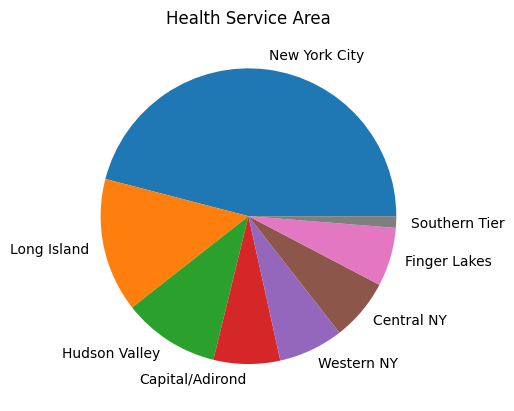

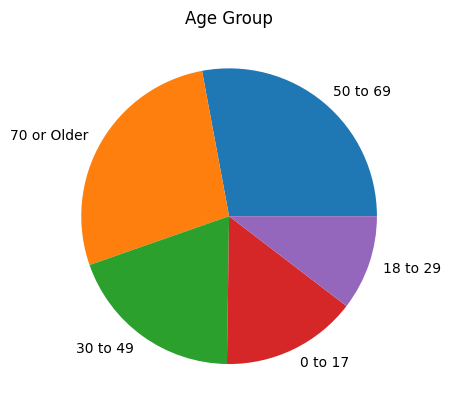

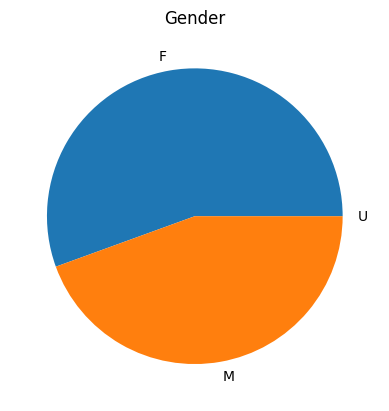

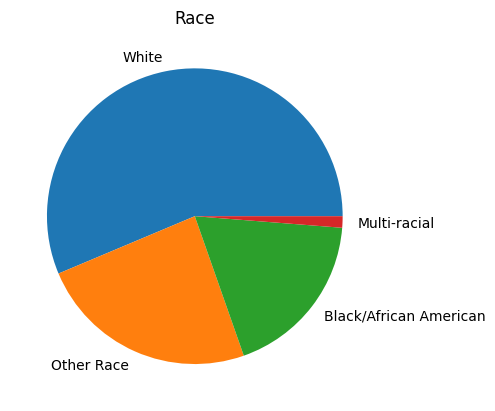

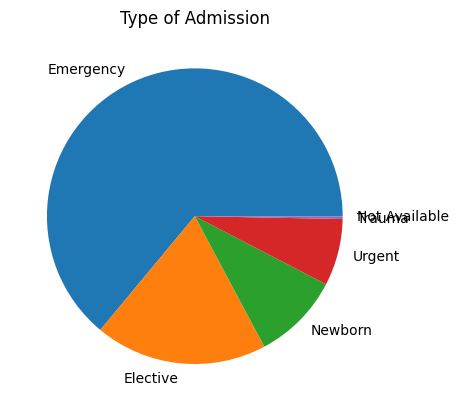

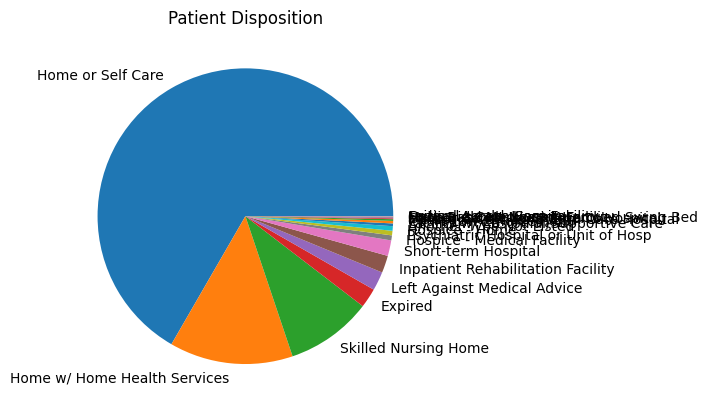

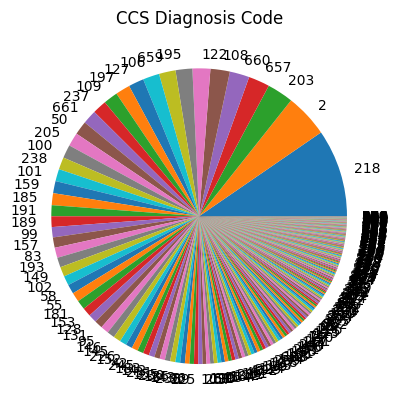

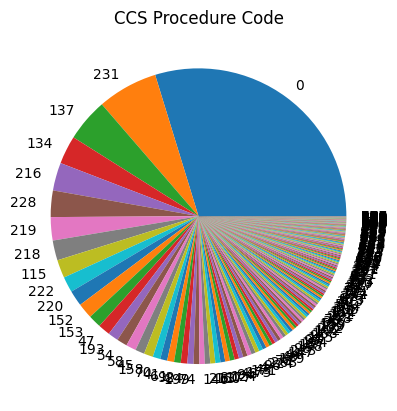

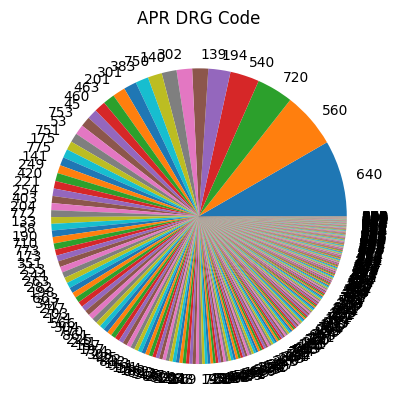

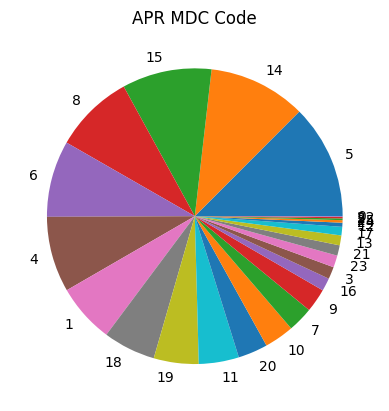

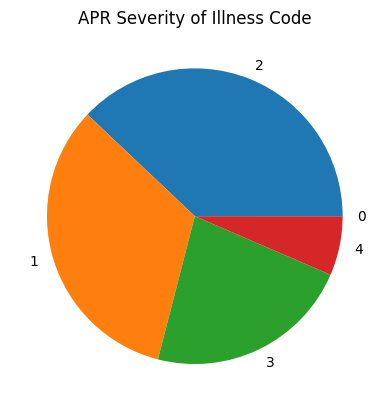

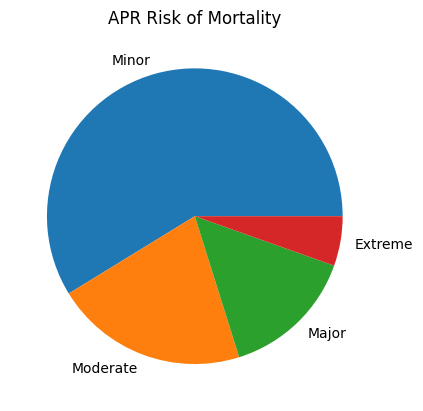

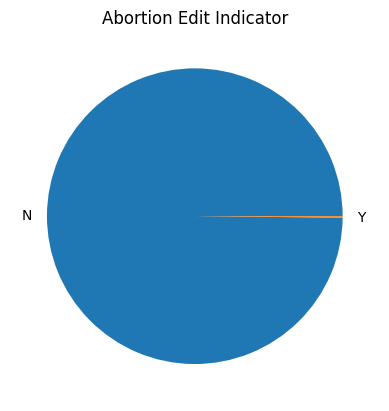

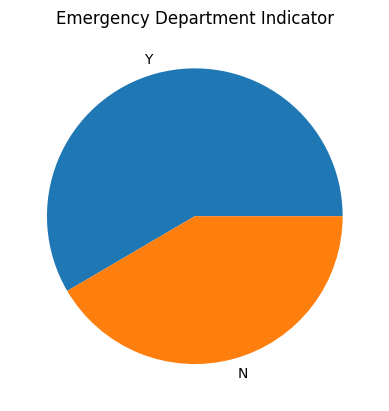

In [10]:
plots_to_make = [ "Health Service Area", "Age Group", "Gender", "Race", "Type of Admission", "Patient Disposition", "CCS Diagnosis Code", "CCS Procedure Code", "APR DRG Code", "APR MDC Code", "APR Severity of Illness Code", "APR Risk of Mortality", "Abortion Edit Indicator", "Emergency Department Indicator"]
for i in plots_to_make:
    counts_for_hs = db[i].value_counts()
    labels = counts_for_hs.index
    values = counts_for_hs.values

# Plot the chart
    plt.pie(values, labels=labels)
    plt.title(i)
    plt.show()

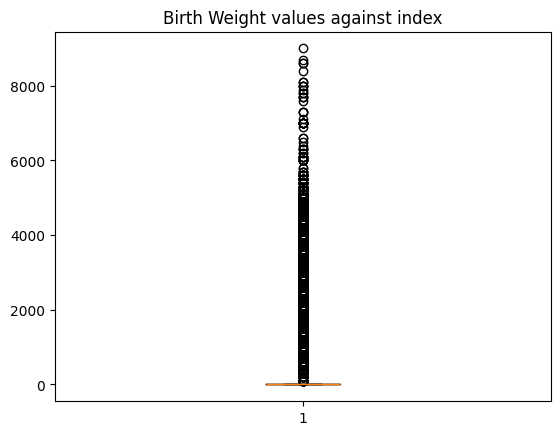

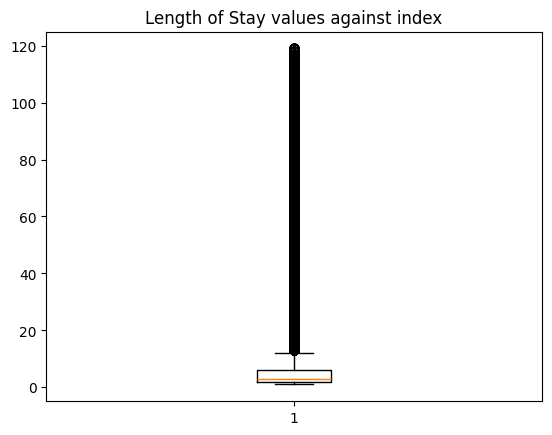

In [11]:
plots_to_make_numerical = ["Birth Weight", "Length of Stay"]
for i in plots_to_make_numerical:
    col = pd.to_numeric(db[i], errors='coerce').dropna()
    plt.boxplot(col)
    plt.title(f"{i} values against index")
    plt.show()

In [12]:
codes_features = ["CCS Diagnosis Code", "CCS Procedure Code", "APR DRG Code", "APR MDC Code"]
for i in codes_features:
    print(f"Unique categories in {i}: {db[i].nunique()}")


Unique categories in CCS Diagnosis Code: 264
Unique categories in CCS Procedure Code: 226
Unique categories in APR DRG Code: 316
Unique categories in APR MDC Code: 26


1. Scale Birth weight
2. One Hot Encode Features
3. Normalize birth weight column
4. Handle Codes features

## One hot encoding for the features with less number of unique categories

In [13]:
def one_hot_encoder(df_list: list):
    encoder = OneHotEncoder(dtype=int, sparse_output=False).set_output(transform="pandas")
    df_transformed = pd.DataFrame()
    for i in df_list:
        if isinstance(db[[i]],pd.DataFrame):
           result = encoder.fit_transform(db[[i]])
           df_transformed = pd.concat([df_transformed,result], axis=1)
    return df_transformed
    
encoders_needed_with_one_hot = [ "Health Service Area", "Age Group", "Gender", "Race", "Type of Admission", "Patient Disposition", "APR Severity of Illness Code", "APR Risk of Mortality", "Abortion Edit Indicator", "Emergency Department Indicator"]
encoders_needed_with_label_encoding = ["CCS Diagnosis Code", "CCS Procedure Code", "APR DRG Code", "APR MDC Code"]
df1 = one_hot_encoder(encoders_needed_with_one_hot)
df1.head()

,Health Service Area_Capital/Adirond,Health Service Area_Central NY,Health Service Area_Finger Lakes,Health Service Area_Hudson Valley,Health Service Area_Long Island,Health Service Area_New York City,Health Service Area_Southern Tier,Health Service Area_Western NY,Health Service Area_nan,Age Group_0 to 17,...,APR Severity of Illness Code_4,APR Risk of Mortality_Extreme,APR Risk of Mortality_Major,APR Risk of Mortality_Minor,APR Risk of Mortality_Moderate,APR Risk of Mortality_nan,Abortion Edit Indicator_N,Abortion Edit Indicator_Y,Emergency Department Indicator_N,Emergency Department Indicator_Y
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,1,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,1
2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,1
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,1
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,1


## Target Encoding for features with multiple unique categories

In [14]:
def target_encoder(df_list: list):
    encoder = TargetEncoder(smooth="auto", cv=5).set_output(transform="pandas")
    y = pd.to_numeric(db["Length of Stay"].astype(str).str.replace("+", "", regex=False).str.strip(), errors='coerce')
    y = y.fillna(y.median()) 
    df_transformed = pd.DataFrame()
    for i in df_list:
        if isinstance(db[[i]], pd.DataFrame):
           result = encoder.fit_transform(db[[i]], y)
           df_transformed = pd.concat([df_transformed,result], axis=1)
    return df_transformed
    
encoders_needed_with_label_encoding = ["CCS Diagnosis Code", "CCS Procedure Code", "APR DRG Code", "APR MDC Code"]
df2 = target_encoder(encoders_needed_with_label_encoding)
df2.head()

,CCS Diagnosis Code_1,CCS Diagnosis Code_2,CCS Diagnosis Code_3,CCS Diagnosis Code_4,CCS Diagnosis Code_5,CCS Diagnosis Code_6,CCS Diagnosis Code_7,CCS Diagnosis Code_8,CCS Diagnosis Code_9,CCS Diagnosis Code_10,...,APR MDC Code_111,APR MDC Code_112,APR MDC Code_113,APR MDC Code_114,APR MDC Code_115,APR MDC Code_116,APR MDC Code_117,APR MDC Code_118,APR MDC Code_119,APR MDC Code_120
0,0.102282,0.168642,0.174975,0.136036,0.100361,0.074119,0.057282,0.041680,0.028518,0.022211,...,0.000013,0.000013,0.000013,0.000006,0.000013,0.000000,0.000006,0.000006,0.000019,0.000991
1,0.104864,0.169171,0.175129,0.134956,0.099315,0.074713,0.057057,0.040775,0.028556,0.021802,...,0.000013,0.000006,0.000019,0.000013,0.000013,0.000013,0.000006,0.000006,0.000019,0.001046
2,0.107011,0.173854,0.182754,0.149521,0.108719,0.074634,0.055215,0.038172,0.026135,0.017075,...,0.000013,0.000013,0.000013,0.000013,0.000019,0.000013,0.000006,0.000013,0.000019,0.001005
3,0.102372,0.168685,0.177117,0.136512,0.099386,0.073239,0.058098,0.039919,0.028912,0.021958,...,0.000013,0.000013,0.000013,0.000013,0.000019,0.000013,0.000006,0.000013,0.000019,0.001005
4,0.103991,0.169356,0.173272,0.134618,0.099256,0.075074,0.057829,0.041019,0.030302,0.022114,...,0.000013,0.000006,0.000019,0.000013,0.000013,0.000013,0.000006,0.000006,0.000019,0.001046
